# Random Forest - Top model according to the SCPM of -5.53

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# Database Reading and Manipulation
import pandas as pd

# Linear Algebra
import numpy as np

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Modeling
from sklearn.tree import DecisionTreeRegressor

# Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

# Processing
from sklearn.preprocessing import StandardScaler


# Pipeline
from sklearn.pipeline import Pipeline

# Data imputation
from sklearn.impute import SimpleImputer

# Custom modules
## Model selection
from src.cross_validation.blocking_time_series_split import BlockingTimeSeriesSplit

## Function to print scores
from src.utils.print_scores import print_scores

## Function to calculate score regression metrics
from src.utils.score_regression_metrics import score_regression_metrics

## Function to fill the results metric dict
from src.utils.fill_results_dict import fill_results_dict

# Warnings
import warnings

<IPython.core.display.Javascript object>

# Functions and definitions

In [3]:
def get_decision_tree_df_importances(scores):
    importances = {}
    importances_with_column = []
    columns = x.columns

    for index, pipeline in enumerate(scores["estimator"]):
        model = pipeline.named_steps["estimator"]
        importances[index] = model.feature_importances_

    for index, importances_vec in importances.items():
        importances_col = pd.DataFrame(
            {col: [c] for col, c in zip(columns, importances_vec)},
            index=[f"Importances - {index}"],
        )
        importances_with_column.append(importances_col)
    df_importances = pd.concat(importances_with_column)

    return df_importances

<IPython.core.display.Javascript object>

In [4]:
SEED = 47
METRICS = (
    "neg_root_mean_squared_error",
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "r2",
)
METRICS_DICT = {
    "neg_root_mean_squared_error": "RMSE",
    "neg_mean_absolute_error": "MAE",
    "neg_mean_absolute_percentage_error": "MAPE",
    "r2": "R2",
}

<IPython.core.display.Javascript object>

## Defining a dataframe structure to save the results

In [5]:
results_to_save = []

results_dict = {
    "Category": "Local Model",
    "Company": "partner_ii",
    "Features": "Chemical + Mineralogical + Properties CS Less",
    "Data Shape": None,
    "Timesteps": None,
    "Model": "Random Forest",
    "Model Params": None,
    "Scaler": "Standard Scaler",
    "Scaler Params": None,
    "Imputer": "Median",
    "Imputer Params": None,
    "Cross Validation": None,
    "Cross Validation Params": np.nan,
    "RMSE Train": np.nan,
    "MAE Train": np.nan,
    "MAPE Train": np.nan,
    "R2 Train": np.nan,
    "RMSE Test": np.nan,
    "MAE Test": np.nan,
    "MAPE Test": np.nan,
    "R2 Test": np.nan,
}

<IPython.core.display.Javascript object>

# Reading the dataset

In [6]:
df = pd.read_csv("../../../../data/processed/partner_ii/cement-shipping.csv")

<IPython.core.display.Javascript object>

## Defining Features

In this set of experiments we keep only chemical and mineralogical features yielded by the same testing method/procedure

In [7]:
df_copy = df.drop(
    [
        # Properties
        "CS1",
        "CS3",
        "CS7",
        "Cement_Type",
        "CaO",
        "SO3",
        "K2O",
        "Na2O",
        "Loss on Ignition",
        # "C3A",
        # "C4AF",
        # "Free CaO",
        # "Total C3S",
        # "Total C2S",
        "Sieve 45 um",
    ],
    axis=1,
).copy()

<IPython.core.display.Javascript object>

# 1. Decision Tree Regressor

In [8]:
PARAMS = {
    "criterion": "squared_error",
    "max_depth": 3,
    "random_state": SEED,
    "splitter": "best",
}

<IPython.core.display.Javascript object>

<h2>1. Dataset: df_no_cs</h2> <br>In this dataset the CS1, CS3  and CS7 variables are not considered. Only Chemical and mineralogical features measured by the same method. For this particular dataset, all chemical features, with the exception of LOI were measured by XRF and XRD methods.

In [9]:
y = df_copy.pop("CS28").values
x = df_copy.drop(["Date"], axis=1)
dates = df["Date"].copy()

<IPython.core.display.Javascript object>

## 1.3. Time Series Split Cross Validation

In [10]:
repeats = 3
n_splits = 5
gap = 0
pipeline = Pipeline(
    [
        ("estimator", DecisionTreeRegressor(**PARAMS)),
    ]
)
cv = TimeSeriesSplit(gap=gap, max_train_size=None, n_splits=n_splits, test_size=None)

scores = cross_validate(
    pipeline,
    x,
    y,
    scoring=METRICS,
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
    return_indices=True,
)
print("Time Series Split:")
print(f"Repeats: {repeats}")
print(f"n_splits: {n_splits}")
print()
print_scores(scores, METRICS, METRICS_DICT)

results_dict_copy = results_dict.copy()
results_dict_copy["Cross Validation"] = "Time Series Split"
results_dict_copy["Cross Validation Params"] = '{"N_Splits": 5, "Repeats": 1, "Gap": 0}'
results_dict_copy["Data Shape"] = x.shape
df_results = fill_results_dict(results_dict_copy, scores)
results_to_save.append(df_results)

Time Series Split:
Repeats: 3
n_splits: 5

******
[TRAIN]
******
RMSE: -1.927 (0.086)
MAE: -1.534 (0.064)
MAPE: -0.035 (0.001)
R2: 0.668 (0.044)


******
[TEST]
******
RMSE: -2.611 (0.656)
MAE: -2.113 (0.643)
MAPE: -0.050 (0.019)
R2: 0.171 (0.561)




<IPython.core.display.Javascript object>

## Plotting the Predictions

In [11]:
# df_pred = pd.DataFrame()
# df_pred["DATE"] = dates.copy()
# df_pred["CS28"] = y.copy()
# df_pred["CS28_PRED"] = np.nan
# df_pred["SET"] = ""
# df_pred["CEMENT_TYPE"] = df["Cement_Type"].copy()
# df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])


# for idx, pipeline in enumerate(scores["estimator"]):
#     index_train = scores["indices"]["train"][idx]
#     index_test = scores["indices"]["test"][idx]
#     index_preds = np.concatenate([index_train, index_test])

#     # results = scores["estimator"][0].predict(x.loc[index_preds])
#     results = pipeline.predict(x.loc[index_preds])
#     df_pred.loc[index_preds, "CS28_PRED"] = results.copy()
#     df_pred.loc[index_train, "SET"] = "TRAIN"
#     df_pred.loc[index_test, "SET"] = "TEST"
# df_pred = df_pred.dropna()

<IPython.core.display.Javascript object>

In [12]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

In [13]:
df_pred[["DATE", "CS28", "CS28_PRED", "SET"]]

,DATE,CS28,CS28_PRED,SET
0,2020-01-01 11:00:00+00:00,42.93,41.484766,TRAIN
1,2020-01-02 11:00:00+00:00,49.72,48.316939,TRAIN
2,2020-01-02 11:00:00+00:00,39.49,41.484766,TRAIN
3,2020-01-03 11:00:00+00:00,40.55,41.484766,TRAIN
4,2020-01-04 11:00:00+00:00,42.64,41.484766,TRAIN
...,...,...,...,...
1048,2021-12-28 11:00:00+00:00,46.44,48.236034,TEST
1049,2021-12-29 11:00:00+00:00,39.87,40.885161,TEST
1050,2021-12-30 11:00:00+00:00,36.74,40.885161,TEST
1051,2021-12-31 11:00:00+00:00,36.36,40.885161,TEST


<IPython.core.display.Javascript object>

In [14]:
df_copy_copy = df_copy.copy()
df_copy_copy["Date"] = pd.to_datetime(df_copy_copy["Date"])
df_copy_copy["Date"] = df_copy_copy["Date"].dt.tz_localize(None)

df_pred_copy = df_pred.copy()
df_pred_copy["DATE"] = pd.to_datetime(df_pred_copy["DATE"])
df_pred_copy["DATE"] = df_pred_copy["DATE"].dt.tz_localize(None)

df_copy_merge = df_copy_copy.reset_index(drop=True).merge(
    df_pred_copy.reset_index(drop=True), left_index=True, right_index=True, how="inner"
)
df_copy_merge["COMPANY"] = "Partner ii"
df_copy_merge["PLANT"] = "Partner ii"

for fold, (train_index, test_index) in enumerate(cv.split(x)):
    df_copy_merge.loc[train_index, "FOLD"] = fold + 1
    df_copy_merge.loc[test_index, "FOLD"] = fold + 1
df_copy_merge["FOLD"] = df_copy_merge["FOLD"].astype(int)
df_copy_merge.to_excel("local_model_decision_tree_tsscv_partner_ii.xlsx", index=False)
df_copy_merge.to_csv("local_model_decision_tree_tsscv_partner_ii.csv", index=False)

<IPython.core.display.Javascript object>

In [15]:
df_pred

,DATE,CS28,CS28_PRED,SET,FOLD
0,2020-01-01 11:00:00+00:00,42.93,41.484766,TRAIN,1
1,2020-01-02 11:00:00+00:00,49.72,48.316939,TRAIN,1
2,2020-01-02 11:00:00+00:00,39.49,41.484766,TRAIN,1
3,2020-01-03 11:00:00+00:00,40.55,41.484766,TRAIN,1
4,2020-01-04 11:00:00+00:00,42.64,41.484766,TRAIN,1
...,...,...,...,...,...
1048,2021-12-28 11:00:00+00:00,46.44,48.236034,TEST,5
1049,2021-12-29 11:00:00+00:00,39.87,40.885161,TEST,5
1050,2021-12-30 11:00:00+00:00,36.74,40.885161,TEST,5
1051,2021-12-31 11:00:00+00:00,36.36,40.885161,TEST,5


<IPython.core.display.Javascript object>

In [16]:
(df_pred["SET"] == "TEST").sum()

875

<IPython.core.display.Javascript object>

In [17]:
matplotlib.rc_file_defaults()

<IPython.core.display.Javascript object>

In [18]:
df[["CS28"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CS28,1053.0,43.000541,3.530197,34.15,40.66,42.49,45.05,54.56


<IPython.core.display.Javascript object>

In [19]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

In [20]:
df_pred

,DATE,CS28,CS28_PRED,SET,FOLD
0,2020-01-01 11:00:00+00:00,42.93,41.484766,TRAIN,1
1,2020-01-02 11:00:00+00:00,49.72,48.316939,TRAIN,1
2,2020-01-02 11:00:00+00:00,39.49,41.484766,TRAIN,1
3,2020-01-03 11:00:00+00:00,40.55,41.484766,TRAIN,1
4,2020-01-04 11:00:00+00:00,42.64,41.484766,TRAIN,1
...,...,...,...,...,...
1048,2021-12-28 11:00:00+00:00,46.44,48.236034,TEST,5
1049,2021-12-29 11:00:00+00:00,39.87,40.885161,TEST,5
1050,2021-12-30 11:00:00+00:00,36.74,40.885161,TEST,5
1051,2021-12-31 11:00:00+00:00,36.36,40.885161,TEST,5


<IPython.core.display.Javascript object>

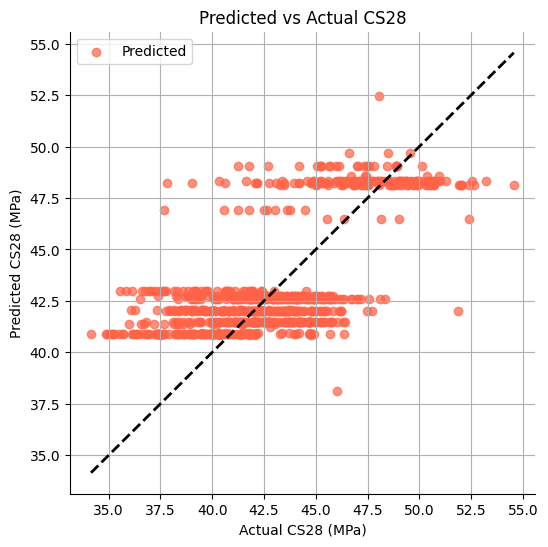

<IPython.core.display.Javascript object>

In [21]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_tiss_scpm_top_one_pred_vs_actual_cs28.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [22]:
# # Time series plot of actual vs predicted values
# plt.figure(figsize=(10, 6))
# plt.plot(
#     test_data["DATE"],
#     test_data["CS28"],
#     color="dodgerblue",
#     alpha=0.7,
#     marker="o",
#     linestyle="none",
#     label="Actual CS28",
# )
# plt.plot(
#     test_data["DATE"],
#     test_data["CS28_PRED"],
#     color="tomato",
#     alpha=0.7,
#     marker="o",
#     linestyle="none",
#     label="Predicted CS28",
# )
# plt.xlabel("Date")
# plt.ylabel("CS28 (MPa)")
# plt.title("Actual vs Predicted CS28")
# plt.legend()
# plt.grid(True)

# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)

# plt.savefig(
#     "inn_cm_tiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
#     dpi=300,
#     bbox_inches="tight",
# )
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'

# plt.show()


<IPython.core.display.Javascript object>

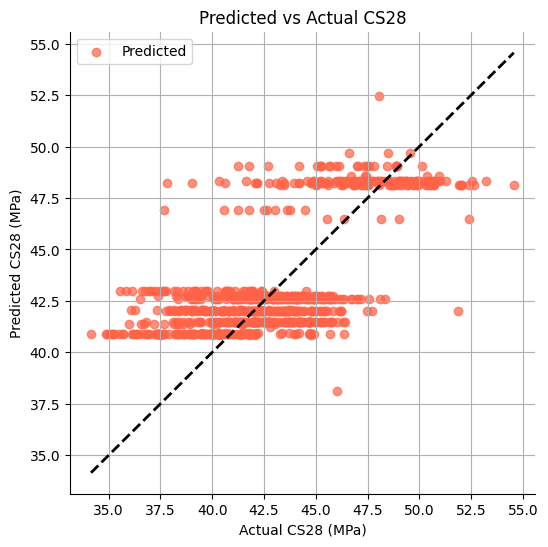

<IPython.core.display.Javascript object>

In [23]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_tiss_scpm_top_one_pred_vs_actual_cs28.png", dpi=300, bbox_inches="tight"
)
plt.show()

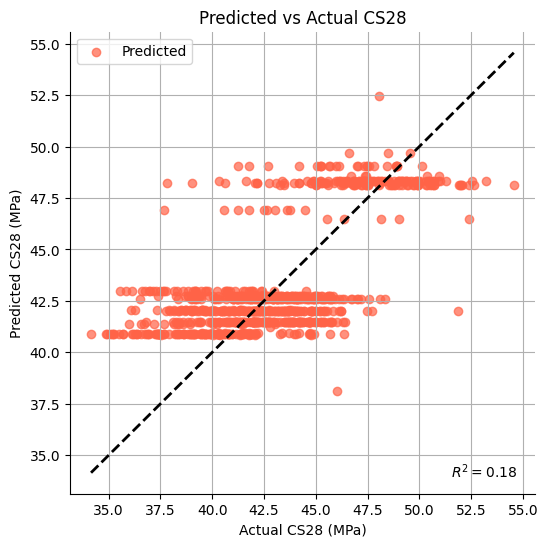

<IPython.core.display.Javascript object>

In [24]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

r2 = 0.18
plt.text(
    0.82,
    0.07,
    f"$R^2 = {r2:.2f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.savefig(
    "inn_cm_p_tiss_scpm_top_one_pred_vs_actual_cs28.png", dpi=300, bbox_inches="tight"
)
plt.show()

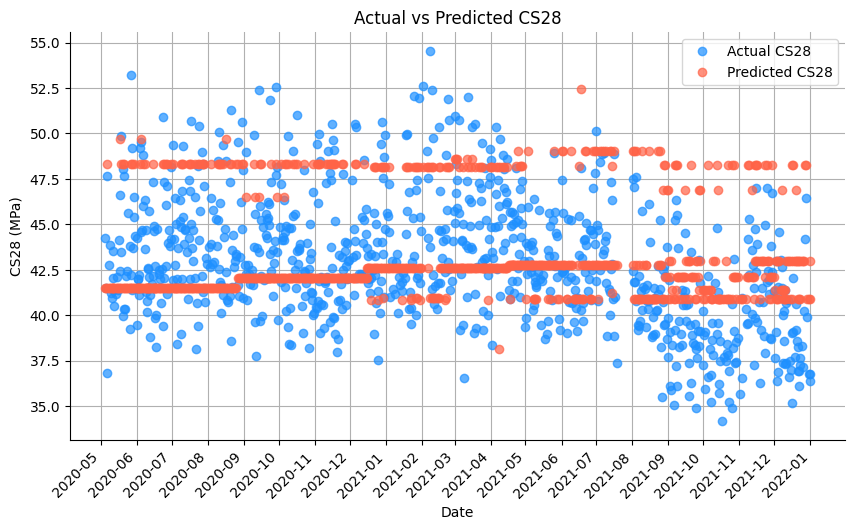

<IPython.core.display.Javascript object>

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_tiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


In [26]:
len(test_data), 175 * 5

(875, 875)

<IPython.core.display.Javascript object>

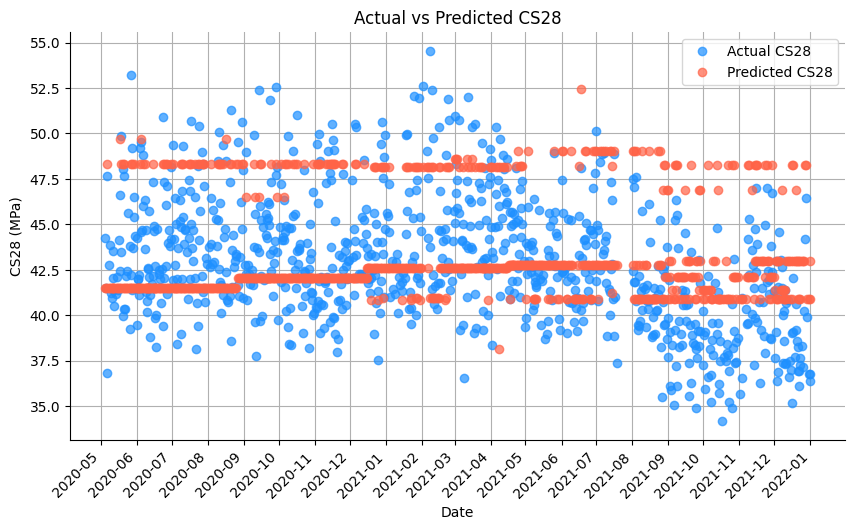

<IPython.core.display.Javascript object>

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "inn_cm_p_tiss_scpm_top_one_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Assessing Feature Importance

In [28]:
df_importances = get_decision_tree_df_importances(scores)

<IPython.core.display.Javascript object>

In [29]:
df_importances

,SiO2,Al2O3,Fe2O3,MgO,Total C3S,Total C2S,C3A,C4AF,Free CaO,Initial setting time,Blaine,Sieve 32 um
Importances - 0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,9.000973,NaN
Importances - 1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,NaN,3.216884,0.000000
Importances - 2,-4.535558,0.000000,0.000000,0.0,0.007384,0.0,0.005267,0.0,0.000000,0.000000,5.333559,0.189348
Importances - 3,0.000000,18.141658,0.000000,0.0,0.233342,0.0,0.139667,0.0,0.000000,-6.595284,-414.131187,6.782009
Importances - 4,0.000000,0.000000,-482.537267,0.0,0.271783,0.0,0.129404,0.0,-0.586227,0.000000,0.000000,5.768312


<IPython.core.display.Javascript object>

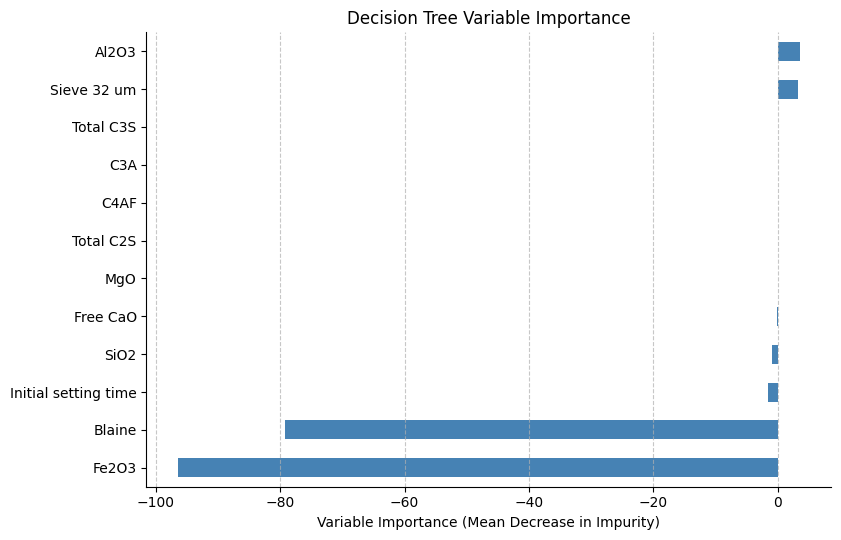

<IPython.core.display.Javascript object>

In [30]:
df_importances.mean(axis=0).sort_values().plot(
    kind="barh", figsize=(10, 5.5), color="steelblue"  # Consider using 'steelblue'
)
plt.title("Decision Tree Variable Importance")
plt.xlabel("Variable Importance (Mean Decrease in Impurity)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()

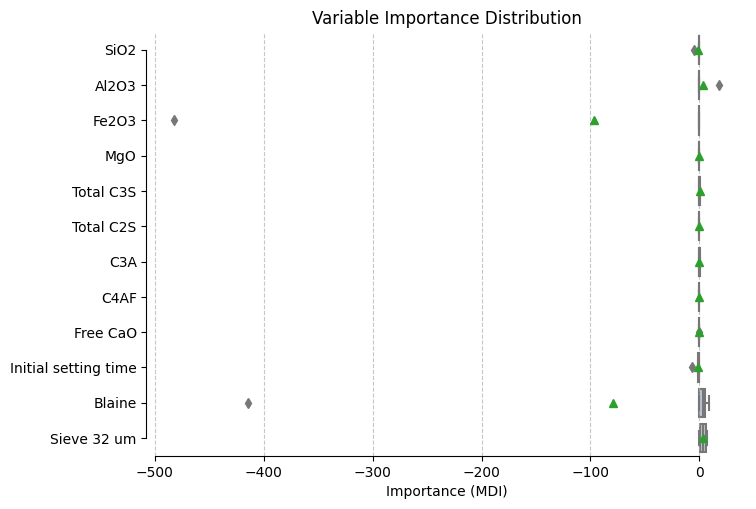

<IPython.core.display.Javascript object>

In [31]:
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 5.5))
sns.boxplot(data=df_importances, orient="h", color="lightsteelblue", saturation=0.7, showmeans=True)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.show()


In [32]:
# warnings.filterwarnings("ignore")
# plt.figure(figsize=(10, 5.5))
# sns.boxplot(data=df_importances, orient="h", color="lightsteelblue", saturation=1, showmeans=True)
# sns.despine(trim=True, left=False)
# plt.xlabel("Relevance (MDI)")
# plt.title("Variable Relevance Distribution")
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.subplots_adjust(left=0.3)
# plt.show()


<IPython.core.display.Javascript object>

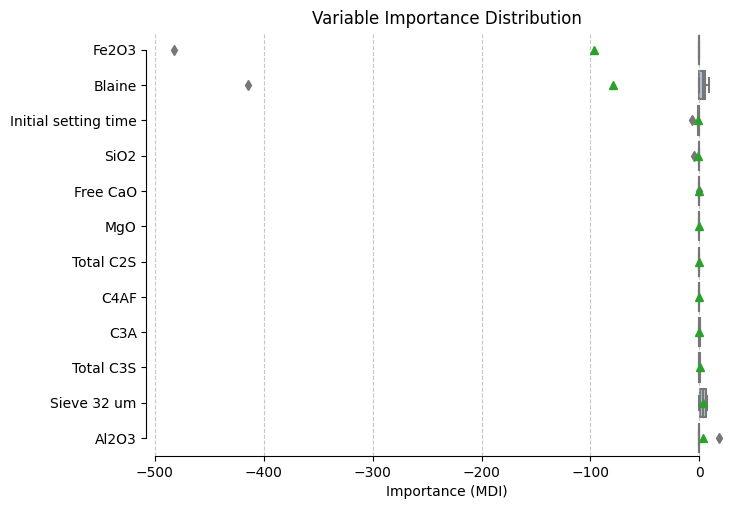

<IPython.core.display.Javascript object>

In [33]:
# Calculate the means of the importance scores
mean_importances = df_importances.mean()

# Sort the features by their mean relevance
sorted_features = mean_importances.sort_values()

# Re-order the DataFrame according to the sorted features
df_importances_sorted = df_importances[sorted_features.index]

# Plot the sorted boxplot
df_importances_sorted = df_importances_sorted.rename(
    columns={"Loss on Ignition": "LOI"}
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_tiss_decision_tree_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [34]:
print("Default font family:", matplotlib.rcParams["font.family"])
print("Default sans-serif fonts:", matplotlib.rcParams["font.sans-serif"])
print("Default font size:", matplotlib.rcParams["font.size"])
print("Default font weight:", matplotlib.rcParams["font.weight"])

Default font family: ['sans-serif']
Default sans-serif fonts: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
Default font size: 10.0
Default font weight: normal


<IPython.core.display.Javascript object>

In [35]:
plt.get_backend()

'module://matplotlib_inline.backend_inline'

<IPython.core.display.Javascript object>

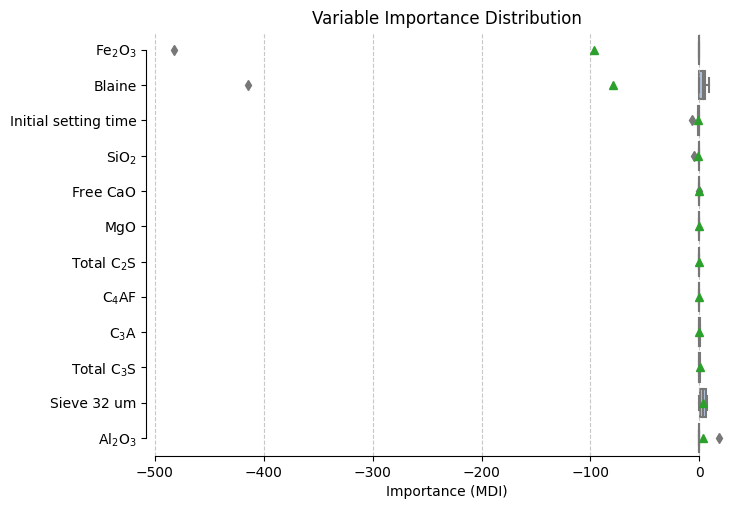

<IPython.core.display.Javascript object>

In [36]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# plt.rcParams.update(
#     {
#         "mathtext.fontset": "custom",
#         "mathtext.rm": "DejaVu Sans",
#         "mathtext.it": "DejaVu Sans:italic",
#         "mathtext.bf": "DejaVu Sans:bold",
#     }
# )


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
    }
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_tiss_decision_tree_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

In [37]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# original_backend = plt.get_backend()

# # Switch to PGF backend to use XeLaTeX
# plt.switch_backend("pgf")

# # Update Matplotlib rcParams
# plt.rcParams.update(
#     {
#         "pgf.texsystem": "xelatex",
#         "font.family": "sans-serif",
#         "font.sans-serif": ["DejaVu Sans"],
#         "font.size": 10,
#         "font.weight": "black",
#         "axes.labelweight": "black",
#         "axes.linewidth": 1.0,
#         "xtick.labelsize": 10,
#         "ytick.labelsize": 10,
#         "text.usetex": True,
#         "pgf.preamble": r"""
#     \usepackage{fontspec}
#     \setmainfont{DejaVu Sans}[
#         UprightFont = *-Book,
#         BoldFont = *-Bold,
#     ]
#     \usepackage{mhchem}
#     \renewcommand{\seriesdefault}{\bfdefault}
#     \bfseries
#     """,
#     }
# )

# # Your plotting code
# df_importances_sorted_plot = df_importances_sorted.rename(
#     columns={
#         "K2O": r"$\ce{K2O}$",
#         "Free CaO": r"Free $\ce{CaO}$ ",
#         "Total C2S": r"Total $\ce{C2S}$",
#         "Na2O": r"$\ce{Na2O}$",
#         "CaO": r"$\ce{CaO}$",
#         "SiO2": r"$\ce{SiO2}$",
#         "MgO": r"$\ce{MgO}$",
#         "Fe2O3": r"$\ce{Fe2O3}$",
#         "Al2O3": r"$\ce{Al2O3}$",
#         "Total C3S": r"Total $\ce{C3S}$",
#         "C3A": r"$\ce{C3A}$",
#         "C4AF": r"$\ce{C4AF}$",
#         "LOI": "LOI",
#         "SO3": r"$\ce{SO3}$",
#     }
# )

# plt.figure(figsize=(10, 5.5))
# sns.boxplot(
#     data=df_importances_sorted_plot,
#     orient="h",
#     color="lightsteelblue",
#     saturation=1,
#     showmeans=True,
# )
# sns.despine(trim=True, left=False)
# plt.xlabel("Relevance (MDI)")
# plt.title("Variable Relevance Distribution")
# plt.grid(axis="x", linestyle="--", alpha=0.7)
# plt.subplots_adjust(left=0.3)
# plt.savefig(
#     "final_plot_with_xelatex.png",
#     dpi=300,
#     bbox_inches="tight",
# )


# # Step 3: Reset all rcParams to their default values
# plt.rcdefaults()

# # Switch back to the original backend
# plt.switch_backend(original_backend)

# # Now you can display the plot or continue plotting with the original backend
# plt.show()

<IPython.core.display.Javascript object>

In [38]:
df_importances

,SiO2,Al2O3,Fe2O3,MgO,Total C3S,Total C2S,C3A,C4AF,Free CaO,Initial setting time,Blaine,Sieve 32 um
Importances - 0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,9.000973,NaN
Importances - 1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,NaN,3.216884,0.000000
Importances - 2,-4.535558,0.000000,0.000000,0.0,0.007384,0.0,0.005267,0.0,0.000000,0.000000,5.333559,0.189348
Importances - 3,0.000000,18.141658,0.000000,0.0,0.233342,0.0,0.139667,0.0,0.000000,-6.595284,-414.131187,6.782009
Importances - 4,0.000000,0.000000,-482.537267,0.0,0.271783,0.0,0.129404,0.0,-0.586227,0.000000,0.000000,5.768312


<IPython.core.display.Javascript object>

In [39]:
df_importances.describe().T

,count,mean,std,min,25%,50%,75%,max
SiO2,5.0,-0.907112,2.028363,-4.535558,0.000000,0.000000,0.000000,0.000000
Al2O3,5.0,3.628332,8.113196,0.000000,0.000000,0.000000,0.000000,18.141658
Fe2O3,5.0,-96.507453,215.797226,-482.537267,0.000000,0.000000,0.000000,0.000000
MgO,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Total C3S,5.0,0.102502,0.137691,0.000000,0.000000,0.007384,0.233342,0.271783
Total C2S,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
C3A,5.0,0.054868,0.072849,0.000000,0.000000,0.005267,0.129404,0.139667
C4AF,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Free CaO,5.0,-0.117245,0.262169,-0.586227,0.000000,0.000000,0.000000,0.000000
Initial setting time,4.0,-1.648821,3.297642,-6.595284,-1.648821,0.000000,0.000000,0.000000


<IPython.core.display.Javascript object>

In [40]:
df_importances.mean(axis=0)

SiO2                    -0.907112
Al2O3                    3.628332
Fe2O3                  -96.507453
MgO                      0.000000
Total C3S                0.102502
Total C2S                0.000000
C3A                      0.054868
C4AF                     0.000000
Free CaO                -0.117245
Initial setting time    -1.648821
Blaine                 -79.315954
Sieve 32 um              3.184917
dtype: float64

<IPython.core.display.Javascript object>

In [41]:
df_importances.std(axis=0)

SiO2                      2.028363
Al2O3                     8.113196
Fe2O3                   215.797226
MgO                       0.000000
Total C3S                 0.137691
Total C2S                 0.000000
C3A                       0.072849
C4AF                      0.000000
Free CaO                  0.262169
Initial setting time      3.297642
Blaine                  187.195986
Sieve 32 um               3.593055
dtype: float64

<IPython.core.display.Javascript object>

In [42]:
df_importances.std(axis=0, ddof=0)

SiO2                      1.814223
Al2O3                     7.256663
Fe2O3                   193.014907
MgO                       0.000000
Total C3S                 0.123155
Total C2S                 0.000000
C3A                       0.065158
C4AF                      0.000000
Free CaO                  0.234491
Initial setting time      2.855842
Blaine                  167.433180
Sieve 32 um               3.111677
dtype: float64

<IPython.core.display.Javascript object>

In [43]:
df_copy.nunique()

Date                    693
SiO2                    182
Al2O3                    89
Fe2O3                    56
MgO                     178
Total C3S               630
Total C2S               561
C3A                     232
C4AF                    224
Free CaO                 98
Initial setting time     23
Blaine                  149
Sieve 32 um             538
dtype: int64

<IPython.core.display.Javascript object>

In [44]:
pipeline.named_steps

{'estimator': DecisionTreeRegressor(max_depth=3, random_state=47)}

<IPython.core.display.Javascript object>

In [45]:
from sklearn.inspection import permutation_importance

<IPython.core.display.Javascript object>

In [46]:
# Initialize lists to store importance results
mdi_importances = []
perm_importances = []

# Compute feature importances
for i, (train_idx, test_idx) in enumerate(cv.split(x, y)):
    pipeline.fit(x.iloc[train_idx], y[train_idx])

    # Extract the trained model
    model = pipeline.named_steps["estimator"]
    # imputer = pipeline.named_steps["imputer"]
    # Compute MDI importance
    mdi_importances.append(model.feature_importances_)

    # Compute permutation importance
    result = permutation_importance(
        model,
        x.iloc[test_idx],
        # imputer.transform(x.iloc[test_idx]),
        y[test_idx],
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
        # scoring="neg_mean_squared_error",
        scoring="r2",
    )
    perm_importances.append(result.importances_mean)

<IPython.core.display.Javascript object>

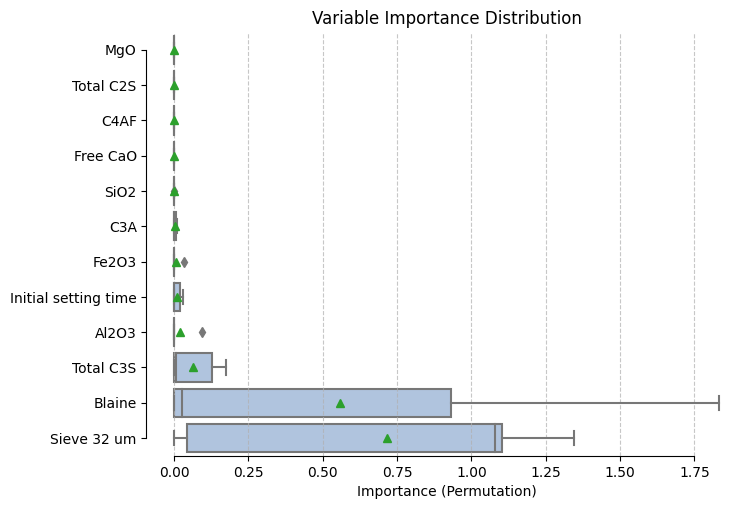

<IPython.core.display.Javascript object>

In [47]:
# Convert lists to DataFrames
mdi_importances_df = pd.DataFrame(mdi_importances, columns=x.columns)
perm_importances_df = pd.DataFrame(perm_importances, columns=x.columns)


# Calculate the mean importance for each feature
mean_importances = perm_importances_df.mean().sort_values()

# Reorder the DataFrame columns based on mean importance
perm_importances_df = perm_importances_df[mean_importances.index]

perm_importances_df = perm_importances_df.rename(columns={"Loss on Ignition": "LOI"})


plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_tiss_decision_tree_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# # Step 3: Reset all rcParams to their default values
plt.rcdefaults()

plt.show()

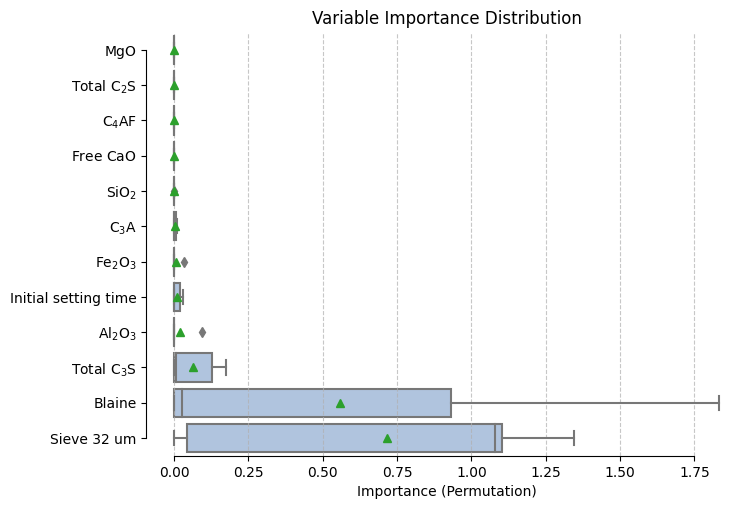

<IPython.core.display.Javascript object>

In [48]:
# Backup the original backend
original_backend = plt.get_backend()

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
    }
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "inn_cm_tiss_decision_tree_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

plt.show()

In [49]:
perm_importances_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MgO,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Total C2S,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
C4AF,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Free CaO,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SiO2,5.0,0.000029,0.000064,0.000000,0.000000,0.000000,0.000000,0.000144
C3A,5.0,0.003183,0.004663,0.000000,0.000000,0.000009,0.005599,0.010309
Fe2O3,5.0,0.006677,0.014929,0.000000,0.000000,0.000000,0.000000,0.033383
Initial setting time,5.0,0.010408,0.014593,0.000000,0.000000,0.000000,0.021590,0.030453
Al2O3,5.0,0.019068,0.042638,0.000000,0.000000,0.000000,0.000000,0.095341
Total C3S,5.0,0.062524,0.083656,0.000000,0.000000,0.008127,0.128634,0.175862


<IPython.core.display.Javascript object>

In [50]:
perm_importances_df

,MgO,Total C2S,C4AF,Free CaO,SiO2,C3A,Fe2O3,Initial setting time,Al2O3,Total C3S,Blaine,Sieve 32 um
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.833594,0.043879
1,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.021590,0.000000,0.000000,0.933233,0.000000
2,0.0,0.0,0.0,0.0,0.000144,0.005599,0.000000,0.000000,0.000000,0.008127,0.027939,1.104350
3,0.0,0.0,0.0,0.0,0.000000,0.000009,0.000000,0.030453,0.095341,0.128634,-0.000889,1.345190
4,0.0,0.0,0.0,0.0,0.000000,0.010309,0.033383,0.000000,0.000000,0.175862,0.000000,1.081145


<IPython.core.display.Javascript object>

In [51]:
perm_importances_df.mean(axis=0)

MgO                     0.000000
Total C2S               0.000000
C4AF                    0.000000
Free CaO                0.000000
SiO2                    0.000029
C3A                     0.003183
Fe2O3                   0.006677
Initial setting time    0.010408
Al2O3                   0.019068
Total C3S               0.062524
Blaine                  0.558775
Sieve 32 um             0.714913
dtype: float64

<IPython.core.display.Javascript object>

In [52]:
perm_importances_df.std(axis=0, ddof=0)

MgO                     0.000000
Total C2S               0.000000
C4AF                    0.000000
Free CaO                0.000000
SiO2                    0.000057
C3A                     0.004170
Fe2O3                   0.013353
Initial setting time    0.013052
Al2O3                   0.038136
Total C3S               0.074824
Blaine                  0.731112
Sieve 32 um             0.573485
dtype: float64

<IPython.core.display.Javascript object>

In [53]:
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.barh(importances_df["Feature"], importances_df["Permutation Importance Mean"], xerr=importances_df["Permutation Importance Std"], color="salmon", alpha=0.7, label="Permutation Importance")
# ax.set_title("Feature Importance: MDI vs Permutation with Standard Deviation")
# ax.set_xlabel("Importance Score")
# ax.legend()
# plt.tight_layout()
# plt.show()


<IPython.core.display.Javascript object>